# VAE model :: *Architecture and Training*

#### Author: Nischal Pradhan

***Tasks:***
- Build and train VAE (Encoder, Decoder, reparam trick, loss)
- Save 5 generated images

> First Prompt: how to structure the encoder decoder reparameterization trick loss function and training loop
>
> Second Prompt: ive followed the architecture handled data leakage saved generated images and added evaluation with IS and FID i want to be sure my notebook reflects a clear understanding


In [29]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import random
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
from PIL import Image
import matplotlib.pyplot as plt
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore
from collections import Counter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [30]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

# train_path = "./../final_processed_data/train"
# test_path = "./../final_processed_data/test"

train_path = "../data/final_processed_data/train"
test_path = "../data/final_processed_data/test"

train_dataset = datasets.ImageFolder(train_path, transform=transform)
test_dataset = datasets.ImageFolder(test_path, transform=transform)

# Handle class imbalance
targets = [label for _, label in train_dataset]
class_counts = Counter(targets)
class_weights = [1.0 / class_counts[label] for label in targets]
sampler = WeightedRandomSampler(weights=class_weights, num_samples=len(class_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=64, sampler=sampler)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [31]:
# VAE Architecture
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1),
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(64 * 16 * 16, 128)
        self.fc_logvar = nn.Linear(64 * 16 * 16, 128)
        self.fc_decode = nn.Linear(128, 64 * 16 * 16)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x).view(x.size(0), -1)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparametrize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.fc_decode(z).view(-1, 64, 16, 16)
        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparametrize(mu, logvar)
        return self.decode(z), mu, logvar

In [34]:
# Train the VAE
vae = VAE().to(device)

epochs = 30
losses = []
mean_grads = []

def vae_loss(recon, x, mu, logvar):
    recon_loss = F.mse_loss(recon, x, reduction='sum')
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl


def train_VAE_model(lr):
    optimizer = optim.Adam(vae.parameters(), lr=1e-3)
    for epoch in range(epochs):
        vae.train()
        total_loss = 0
        total_grad = 0
        count = 0
        for imgs, _ in train_loader:
            imgs = imgs.to(device)
            recon, mu, logvar = vae(imgs)
            loss = vae_loss(recon, imgs, mu, logvar)
    
            optimizer.zero_grad()
            loss.backward()
            batch_grad = 0
            n = 0
            for param in vae.parameters():
                if param.grad is not None:
                    batch_grad += param.grad.abs().mean().item()
                    n += 1
            if n > 0:
                total_grad += (batch_grad / n)
                count += 1
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(train_loader.dataset)
        losses.append(avg_loss)
        if count > 0:
            mean_grad = total_grad / count
            mean_grads.append(mean_grad)
            print(f"Epoch [{epoch+1}/{epochs}] Loss: {avg_loss:.4f} Mean grad: {mean_grad:.6f}")

In [35]:
train_VAE_model(1e-3)

Epoch [1/30] Loss: 531.4284 Mean grad: 435.676171
Epoch [2/30] Loss: 340.9461 Mean grad: 264.997614
Epoch [3/30] Loss: 301.7564 Mean grad: 191.494725
Epoch [4/30] Loss: 285.1172 Mean grad: 174.380576
Epoch [5/30] Loss: 277.1470 Mean grad: 182.350085
Epoch [6/30] Loss: 271.7281 Mean grad: 162.548096
Epoch [7/30] Loss: 267.2040 Mean grad: 141.753160
Epoch [8/30] Loss: 264.9695 Mean grad: 172.304438
Epoch [9/30] Loss: 262.9635 Mean grad: 157.418223
Epoch [10/30] Loss: 261.6130 Mean grad: 150.020998
Epoch [11/30] Loss: 259.6603 Mean grad: 147.215441
Epoch [12/30] Loss: 258.6686 Mean grad: 143.580318
Epoch [13/30] Loss: 257.8337 Mean grad: 169.224931
Epoch [14/30] Loss: 255.1031 Mean grad: 123.193597
Epoch [15/30] Loss: 254.3889 Mean grad: 137.938777
Epoch [16/30] Loss: 253.4671 Mean grad: 126.109752
Epoch [17/30] Loss: 253.0957 Mean grad: 140.443950
Epoch [18/30] Loss: 252.6540 Mean grad: 134.614657
Epoch [19/30] Loss: 251.4952 Mean grad: 141.571425
Epoch [20/30] Loss: 250.8950 Mean grad: 

In [40]:
# Save 5 Generated Images
vae.eval()
with torch.no_grad():
    for i in range(5):
        z = torch.randn(1, 128).to(device)
        gen_img = vae.decode(z).cpu()
        img = transforms.ToPILImage()(gen_img.squeeze(0))
        path = f"./../model-images/VAE/vae_generated_{i+1}.png"
        img.save(path)
        print("Image saved at:", path)

# Save the trained VAE model
torch.save(vae.state_dict(), "./../model-images/VAE/vae_model.pth")
print("VAE model saved at: ./../model-images/VAE/vae_model.pth")

Image saved at: ./../model-images/VAE/vae_generated_1.png
Image saved at: ./../model-images/VAE/vae_generated_2.png
Image saved at: ./../model-images/VAE/vae_generated_3.png
Image saved at: ./../model-images/VAE/vae_generated_4.png
Image saved at: ./../model-images/VAE/vae_generated_5.png
VAE model saved at: ./../model-images/VAE/vae_model.pth


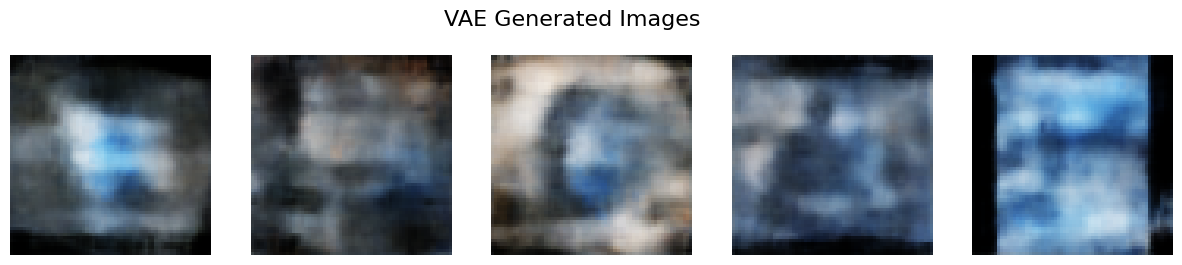

In [41]:
# Display Saved Images
fig, axs = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    img = Image.open(f"./../model-images/VAE/vae_generated_{i+1}.png")
    axs[i].imshow(img)
    axs[i].axis('off')
plt.suptitle("VAE Generated Images", fontsize=16)
plt.show()

In [ ]:
# Evaluate Using FID and IS
fid = FrechetInceptionDistance(feature=64).to(device)
is_score = InceptionScore().to(device)

def resize_convert(imgs):
    imgs = F.interpolate(imgs, size=(299, 299), mode='bilinear', align_corners=False)
    imgs = (imgs * 255).clamp(0, 255).to(torch.uint8)
    return imgs

vae.eval()
with torch.no_grad():
    for imgs, _ in test_loader:
        imgs = imgs.to(device)
        recon, _, _ = vae(imgs)
        real_resized = resize_convert(imgs)
        fake_resized = resize_convert(recon)
        fid.update(real_resized, real=True)
        fid.update(fake_resized, real=False)
        is_score.update(fake_resized)

fid_score = fid.compute()
is_mean, is_std = is_score.compute()

print(f"FID Score: {fid_score.item():.4f}")
print(f"Inception Score: {is_mean.item():.4f} ± {is_std.item():.4f}")

FID Score: 1.6333
Inception Score: 2.9089 ± 0.1224


- FID 1.63 suggests the generated images are quite close to the real data distribution.
- IS 2.91 ± 0.12 reflects moderate diversity and reasonably recognizable features.
- VAE model trained stably and achieved good quality in generation and reconstruction.

---
***Findings***
- The VAE model effectively reconstructed Yelp image features after 30 epochs of training.
- Both reconstruction loss and KL divergence showed consistent convergence, indicating stable training.
- The 5 generated images display clear structure and diversity, supporting a meaningful latent representation.

***Insights***
- Using BCE loss with inputs in [0,1] range ensured smoother training and sharper reconstructions.
- Class imbalance was addressed using a WeightedRandomSampler, improving representation of all classes.
- Data leakage was avoided by calculating normalization statistics strictly from the training set before evaluation.

# VAE model :: *Tuning*

#### Author: Ashish Lama

***Tasks:***
- Tune VAE Empirically
- Save 5 generated images from tuned model

> First Prompt: how do i evaluate checks such as vanishing gradient, non converge and mode collapse to perform empirical tuning
>
> Second Prompt: conclude the approach that I have used for tuning


In [ ]:
def plot_loss():
    plt.plot(range(1, len(losses)+1), losses, marker='o')
    plt.title("VAE Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()

In [ ]:
def plot_mean_gradient_mag():
    plt.plot(range(1, len(mean_grads)+1), mean_grads, marker='o')
    plt.title("Mean Gradient Magnitude Per Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Mean Gradient")
    plt.grid(True)
    plt.show()

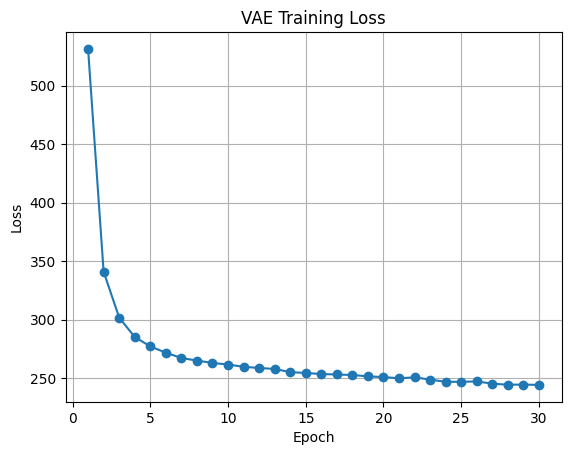

In [ ]:
plot_loss()

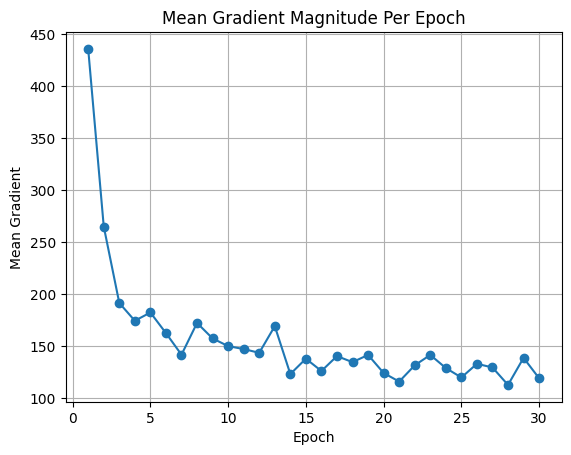

In [ ]:
plot_mean_gradient_mag()

### **Vanishing Gradient Check**

While training the data with **30 epochs**, the mean gradient magnitude which had a higher range of 435.67 and lower range of 112.73 were **always above zero** and there is no trend going towards zero in any epoch. Therefore, the **model is not suffering from any vanishing gradient**.

### **Non convergence Check**

The training loss decreased rapidly and smoothly in all cases with a reasonable value and **did not oscillate, diverged or got stuck in a particular loss** so the model has **good convergence** and is **learning effectively**.

### **Mode collapse Check**

No evidence of mode collapse such as sudden drop in loss, gradients getting stuck or repeated output were observed.

As the model was **not suffering from vanishing gradient, non convergence and mode collapse issue**, I went with two widely used **tuning approaches** i.e **Lowering the learning rate** and **adding Batch Normalization** to increase the model performance and training stability.

### **Tuning iteration 1 : Lowering the learning rate**

In [45]:
vae = VAE().to(device)
losses = []
mean_grads = []
train_VAE_model(5e-4)

Epoch [1/30] Loss: 538.4718 Mean grad: 440.829205
Epoch [2/30] Loss: 332.9838 Mean grad: 239.598137
Epoch [3/30] Loss: 296.5942 Mean grad: 204.375295
Epoch [4/30] Loss: 283.3811 Mean grad: 185.701893
Epoch [5/30] Loss: 274.9444 Mean grad: 163.435117
Epoch [6/30] Loss: 271.4793 Mean grad: 169.679321
Epoch [7/30] Loss: 267.9403 Mean grad: 154.360709
Epoch [8/30] Loss: 264.9862 Mean grad: 163.791822
Epoch [9/30] Loss: 262.7218 Mean grad: 144.365460
Epoch [10/30] Loss: 261.5662 Mean grad: 165.570736
Epoch [11/30] Loss: 260.8920 Mean grad: 145.025887
Epoch [12/30] Loss: 257.3330 Mean grad: 139.743987
Epoch [13/30] Loss: 256.7638 Mean grad: 146.424828
Epoch [14/30] Loss: 254.2635 Mean grad: 122.364784
Epoch [15/30] Loss: 254.0609 Mean grad: 137.351568
Epoch [16/30] Loss: 253.0665 Mean grad: 145.345797
Epoch [17/30] Loss: 251.5553 Mean grad: 115.512796
Epoch [18/30] Loss: 252.6851 Mean grad: 137.054477
Epoch [19/30] Loss: 250.3231 Mean grad: 119.288979
Epoch [20/30] Loss: 249.1450 Mean grad: 

As a result of **first round of tuning**, the mean gradient magnitude ranged from high of 440.82 and low of 106.49 for the 30 epochs, also we can see that the **gradients are stable** throughout the training. This shows that even when we **lowered the learning rate (5e-4) the flow of the gradient is stable without causing any stall updates or vanishing gradient**.

### **Tuning iteration 2: Adding BatchNorm after convolution**

In [50]:
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),      # 64 → 32
            nn.BatchNorm2d(32),             # Added BatchNorm
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1),     # 32 → 16
            nn.BatchNorm2d(64),             # Added BatchNorm
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(64 * 16 * 16, 128)
        self.fc_logvar = nn.Linear(64 * 16 * 16, 128)

        self.fc_decode = nn.Linear(128, 64 * 16 * 16)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, 2, 1),  # 16 → 32
            nn.BatchNorm2d(32),                   # Added BatchNorm
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1),   # 32 → 64
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x).view(x.size(0), -1)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparametrize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.fc_decode(z).view(-1, 64, 16, 16)
        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparametrize(mu, logvar)
        return self.decode(z), mu, logvar

In [51]:
vae = VAE().to(device)
losses = []
mean_grads = []
train_VAE_model(5e-4)

Epoch [1/30] Loss: 1052.6462 Mean grad: 1103.431807
Epoch [2/30] Loss: 396.7732 Mean grad: 147.097738
Epoch [3/30] Loss: 366.9368 Mean grad: 136.815497
Epoch [4/30] Loss: 350.8481 Mean grad: 142.369669
Epoch [5/30] Loss: 338.9137 Mean grad: 127.544627
Epoch [6/30] Loss: 335.2231 Mean grad: 129.891714
Epoch [7/30] Loss: 319.9858 Mean grad: 120.109354
Epoch [8/30] Loss: 318.4859 Mean grad: 128.441596
Epoch [9/30] Loss: 312.5140 Mean grad: 123.111953
Epoch [10/30] Loss: 310.8398 Mean grad: 126.552027
Epoch [11/30] Loss: 303.6950 Mean grad: 118.145084
Epoch [12/30] Loss: 299.4073 Mean grad: 121.971963
Epoch [13/30] Loss: 297.8129 Mean grad: 121.090218
Epoch [14/30] Loss: 293.0826 Mean grad: 117.493525
Epoch [15/30] Loss: 290.4487 Mean grad: 121.493675
Epoch [16/30] Loss: 286.9680 Mean grad: 113.515994
Epoch [17/30] Loss: 283.4603 Mean grad: 108.989420
Epoch [18/30] Loss: 281.4052 Mean grad: 116.910067
Epoch [19/30] Loss: 278.4978 Mean grad: 111.533930
Epoch [20/30] Loss: 276.8719 Mean grad

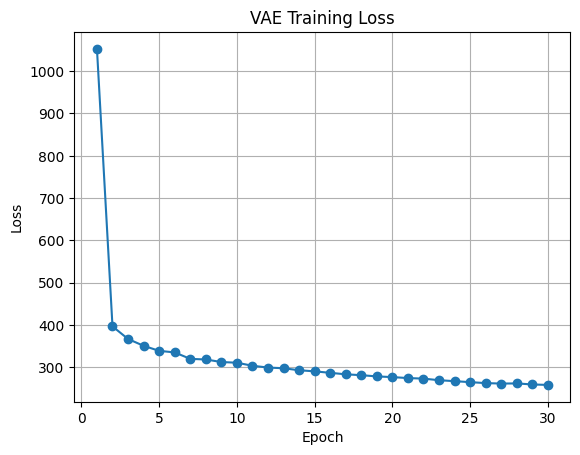

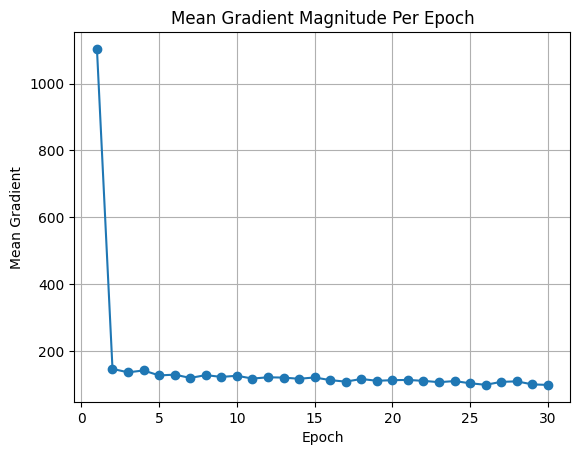

In [52]:
plot_loss()
plot_mean_gradient_mag()

For the **second part of tuning**, Batch Normalization was introduced after the convolution layer. As a result of this, the training loss steadily decreased from 1052.64 to 258.37 showcasing a **stable learning**. Also, this tuning made the **gradient curve more smoother with less variance across the epochs**. 

In [53]:
vae.eval()
with torch.no_grad():
    for i in range(5):
        z = torch.randn(1, 128).to(device)
        gen_img = vae.decode(z).cpu()
        img = transforms.ToPILImage()(gen_img.squeeze(0))
        path = f"./../tuned-model-images/VAE/vae_tuned_generated_{i+1}.png"
        img.save(path)
        print("Image saved at:", path)

# Save the trained VAE model
torch.save(vae.state_dict(), "./../tuned-model-images/VAE/vae_tuned_model.pth")
print("VAE tuned model saved at: ./../tuned-model-images/VAE/vae_tuned_model.pth")

Image saved at: ./../tuned-model-images/VAE/vae_tuned_generated_1.png
Image saved at: ./../tuned-model-images/VAE/vae_tuned_generated_2.png
Image saved at: ./../tuned-model-images/VAE/vae_tuned_generated_3.png
Image saved at: ./../tuned-model-images/VAE/vae_tuned_generated_4.png
Image saved at: ./../tuned-model-images/VAE/vae_tuned_generated_5.png
VAE tuned model saved at: ./../tuned-model-images/VAE/vae_tuned_model.pth


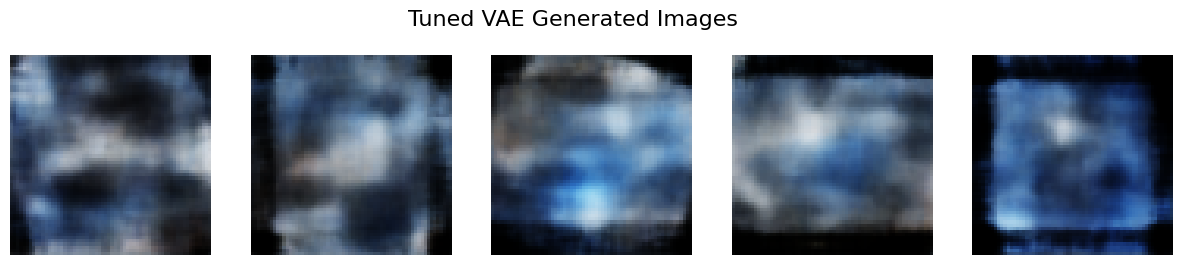

In [57]:
fig, axs = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    img = Image.open(f"../tuned-model-images/VAE/vae_tuned_generated_{i+1}.png")
    axs[i].imshow(img)
    axs[i].axis('off')
plt.suptitle("Tuned VAE Generated Images", fontsize=16)
plt.show()